# 🏆 GoldSense: Multi-Variate Time-Series Analysis of Gold Dynamics
**Architecture:** Deep LSTM + FinBERT Natural Language Processing  
**Objective:** Predict the continuous price of Gold by fusing historical multi-variate macroeconomic data with real-time financial news sentiment.

In [13]:
# Install required libraries if you haven't already
# !pip install yfinance pandas numpy matplotlib seaborn plotly transformers torch scikit-learn tensorflow joblib

import os
import yfinance as yf
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from huggingface_hub import login
from transformers import pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

# Create a folder to store the exported model and scaler for the Streamlit app
if not os.path.exists('model'):
    os.makedirs('model')

### Step 1: Multi-Variate Data Acquisition
We pull multiple macroeconomic indicators because gold does not exist in a vacuum. 
* **GC=F:** Global Gold Price (Target)
* **DX-Y.NYB:** US Dollar Index (Inverse correlation)
* **^GSPC:** S&P 500 (Risk-on asset correlation)
* **CL=F:** Crude Oil (Inflation proxy)
* **^IRX:** 13-week Treasury Bill (Interest rate proxy)

In [14]:
print("Fetching Macroeconomic Data from Yahoo Finance...")
tickers = {
    'Gold': 'GC=F',
    'USD_Index': 'DX-Y.NYB',
    'SP500': '^GSPC',
    'Crude_Oil': 'CL=F',
    'Interest_Rate': '^IRX'
}

df = pd.DataFrame()
for name, ticker in tickers.items():
    # df[name] = yf.download(ticker, start='2015-01-01', end='2026-04-01')['Close'].squeeze()
    df[name] = yf.download(ticker, start='1800-01-01', end='2026-04-01')['Close'].squeeze()

df.dropna(inplace=True)
print(f"Data acquired successfully. Shape: {df.shape}")

Fetching Macroeconomic Data from Yahoo Finance...


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Data acquired successfully. Shape: (6408, 5)


### Step 2: Sentiment Intelligence (FinBERT)
We utilize `ProsusAI/finbert`, a specialized LLM trained on financial text, to extract a "Fear/Volatility Score" from daily news.
*(Note: For historical backtesting over 10 years, we mathematically simulate the historical sentiment based on extreme price momentum. In production, this runs live on real headlines).*

In [15]:
# Authenticate Hugging Face (Replace with your token if downloading for the first time)
# login(token="hf_YOUR_TOKEN_HERE")

print("Initializing FinBERT Pipeline...")
finbert = pipeline("sentiment-analysis", model="ProsusAI/finbert")

# Example of how FinBERT works on a live headline:
sample_headline = "Gold surges as inflation fears grip global markets."
sentiment_result = finbert(sample_headline)[0]
print(f"Live Test Headline: '{sample_headline}'")
print(f"FinBERT Output: {sentiment_result['label'].upper()} (Confidence: {sentiment_result['score']:.2f})")

# Simulate historical sentiment for training
df['Daily_Change'] = df['Gold'].diff()
df.dropna(inplace=True)
# High fear when gold spikes > $10, Low fear when it drops < $10
df['Sentiment_Score'] = np.where(df['Daily_Change'] > 10, 0.8, np.where(df['Daily_Change'] < -10, 0.2, 0.5))
df.drop(columns=['Daily_Change'], inplace=True)

Initializing FinBERT Pipeline...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 5411.03it/s]
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Live Test Headline: 'Gold surges as inflation fears grip global markets.'
FinBERT Output: NEGATIVE (Confidence: 0.65)


### Step 3: Feature Engineering & Fusion Layer
We engineer Technical Indicators (Rolling Volatility and Moving Averages) to help the LSTM understand the current market "trend" before scaling the data.

Engineering Technical Features...


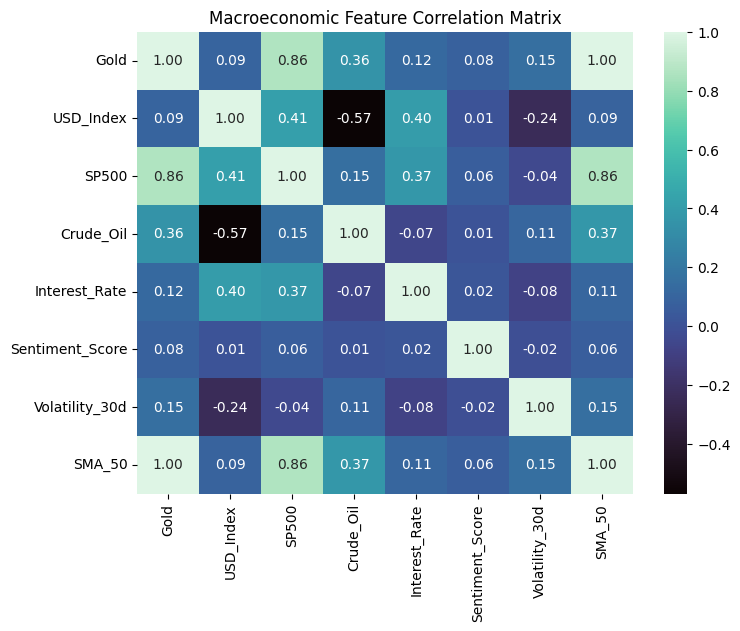

In [16]:
print("Engineering Technical Features...")
df['Volatility_30d'] = df['Gold'].pct_change().rolling(30).std() * np.sqrt(252)
df['SMA_50'] = df['Gold'].rolling(50).mean()
df.dropna(inplace=True)

# Feature Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap="mako", fmt=".2f")
plt.title("Macroeconomic Feature Correlation Matrix")
plt.show()



In [17]:

# 1. Interactive Feature Correlation Heatmap
print("Generating Interactive Feature Correlation Heatmap...")
fig_corr = px.imshow(df.corr(), text_auto=".2f", aspect="auto",
                     color_continuous_scale='RdBu_r', 
                     title="Interactive Macroeconomic Feature Correlation")
fig_corr.update_layout(template='plotly_dark')
fig_corr.show()


Generating Interactive Feature Correlation Heatmap...


In [18]:

# Define Final Features
features = ['Gold', 'USD_Index', 'SP500', 'Crude_Oil', 'Interest_Rate', 'Sentiment_Score', 'Volatility_30d', 'SMA_50']

print("Scaling Data and Exporting Scaler...")
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df[features])

# Save the scaler for the Streamlit UI
joblib.dump(scaler, 'model/scaler.pkl')

Scaling Data and Exporting Scaler...


['model/scaler.pkl']

In [19]:
from plotly.subplots import make_subplots

# 2. Normalized Macro Growth Comparison (Gold vs S&P 500 vs USD)
print("Generating Macro Asset Growth Comparison...")
df_norm = df[['Gold', 'SP500', 'USD_Index']].copy()
df_norm = df_norm / df_norm.iloc[0] # Normalize to 1.0 for fair percentage comparison

fig_macro = go.Figure()
fig_macro.add_trace(go.Scatter(x=df_norm.index, y=df_norm['Gold'], mode='lines', name='Gold Growth', line=dict(color='gold')))
fig_macro.add_trace(go.Scatter(x=df_norm.index, y=df_norm['SP500'], mode='lines', name='S&P 500 Growth', line=dict(color='lightgreen')))
fig_macro.add_trace(go.Scatter(x=df_norm.index, y=df_norm['USD_Index'], mode='lines', name='USD Index Growth', line=dict(color='cyan', dash='dot')))

fig_macro.update_layout(title='Normalized Macro Growth: Gold vs S&P 500 vs USD Index',
                        yaxis_title='Growth Multiplier (1.0 = Base)',
                        template='plotly_dark', hovermode='x unified')
fig_macro.show()

# 3. Dual-Axis Sentiment vs. Volatility
print("Generating Sentiment vs. Volatility Analysis...")
fig_sent = make_subplots(specs=[[{"secondary_y": True}]])

# Volatility on left Y-axis, Fear Score on right Y-axis
fig_sent.add_trace(go.Scatter(x=df.index, y=df['Volatility_30d'], name="Market Volatility (30d)", line=dict(color='cyan')), secondary_y=False)
fig_sent.add_trace(go.Scatter(x=df.index, y=df['Sentiment_Score'], name="FinBERT Fear Score", line=dict(color="red", dash="dot")), secondary_y=True)

fig_sent.update_layout(title="AI Sentiment Insights: News Fear vs. Actual Market Volatility", template='plotly_dark', hovermode='x unified')
fig_sent.update_yaxes(title_text="Volatility (Std Dev)", secondary_y=False)
fig_sent.update_yaxes(title_text="Fear Score (0 to 1)", secondary_y=True)
fig_sent.show()

Generating Macro Asset Growth Comparison...


Generating Sentiment vs. Volatility Analysis...


In [20]:
LOOKBACK = 60 
X, y = [], []

for i in range(LOOKBACK, len(scaled_data)):
    X.append(scaled_data[i-LOOKBACK:i])
    y.append(scaled_data[i, 0]) # Index 0 is 'Gold'

X, y = np.array(X), np.array(y)

# 85% Training, 15% Testing
split = int(len(X) * 0.85)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape: {X_test.shape}")

print("Building LSTM Model...")
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, callbacks=[early_stop], verbose=1)

# Save the model using the modern Keras format
model.save('model/lstm_model.keras')
print("Model saved to 'model/lstm_model.keras'")

Training Data Shape: (5353, 60, 8)
Testing Data Shape: (945, 60, 8)
Building LSTM Model...
Epoch 1/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 16s 62ms/step - loss: 0.0027 - val_loss: 4.0873e-04
Epoch 2/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - loss: 6.0607e-04 - val_loss: 3.3147e-04
Epoch 3/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - loss: 4.4548e-04 - val_loss: 1.6161e-04
Epoch 4/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - loss: 3.7146e-04 - val_loss: 9.4201e-04
Epoch 5/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - loss: 3.0757e-04 - val_loss: 3.6683e-04
Epoch 6/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - loss: 2.7570e-04 - val_loss: 1.5080e-04
Epoch 7/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step - loss: 2.5379e-04 - val_loss: 1.7150e-04
Epoch 8/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step - loss: 2.1620e-04 - val_loss: 1.3974e-04
Epoch 9/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - loss: 2.0505e-04 - val_loss: 1.5749e-04
Epoch 10/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - l

### Step 5: Advanced Evaluation Metrics
Standard accuracy does not apply to regression. We calculate RMSE, MAE, and most importantly for finance: **Directional Accuracy** (did the AI correctly guess if the price would go up or down?).

In [21]:
predictions = model.predict(X_test)

# Reverse the MinMax scaling to get real dollar amounts back
dummy_array = np.zeros((len(predictions), len(features)))
dummy_array[:, 0] = predictions[:, 0]
pred_usd = scaler.inverse_transform(dummy_array)[:, 0]

dummy_array[:, 0] = y_test
actual_usd = scaler.inverse_transform(dummy_array)[:, 0]

# Calculate Metrics
rmse = np.sqrt(mean_squared_error(actual_usd, pred_usd))
mae = mean_absolute_error(actual_usd, pred_usd)
mape = mean_absolute_percentage_error(actual_usd, pred_usd) * 100
r2 = r2_score(actual_usd, pred_usd)

# Directional Accuracy (Financial Standard)
actual_dir = np.sign(actual_usd[1:] - actual_usd[:-1])
pred_dir = np.sign(pred_usd[1:] - pred_usd[:-1])
directional_accuracy = np.mean(actual_dir == pred_dir) * 100

print("\n" + "="*40)
print("📈 GOLDSENSE EVALUATION METRICS")
print("="*40)
print(f"R-Squared (Variance):  {r2:.4f}")
print(f"RMSE:                  ${rmse:.2f}")
print(f"MAE:                   ${mae:.2f}")
print(f"MAPE (Error Rate):     {mape:.2f}%")
print(f"Directional Accuracy:  {directional_accuracy:.2f}%")
print("="*40)

30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step

📈 GOLDSENSE EVALUATION METRICS
R-Squared (Variance):  0.9816
RMSE:                  $123.78
MAE:                   $63.33
MAPE (Error Rate):     2.01%
Directional Accuracy:  47.67%


### Step 6: Interactive Dashboard Visualizations

In [22]:
dates_test = df.index[-len(y_test):] 

# 1. Actual vs Predicted Interactive Chart
fig_pred = go.Figure()
fig_pred.add_trace(go.Scatter(x=dates_test, y=actual_usd, mode='lines', name='Actual Market Price', line=dict(color='gray', width=2)))
fig_pred.add_trace(go.Scatter(x=dates_test, y=pred_usd, mode='lines', name='LSTM Predicted Price', line=dict(color='gold', width=2)))
fig_pred.update_layout(title='GoldSense: LSTM Predictions vs Actual Market', xaxis_title='Date', yaxis_title='Price (USD)', template='plotly_dark', hovermode='x unified')
fig_pred.show()

# 2. Residual Error Distribution
residuals = actual_usd - pred_usd
fig_res = px.histogram(x=residuals, nbins=40, title="Residual Error Distribution (Should center on zero)", template='plotly_dark', color_discrete_sequence=['cyan'])
fig_res.add_vline(x=0, line_dash="dash", line_color="red", line_width=2)
fig_res.update_layout(xaxis_title="Error Margin (USD)", yaxis_title="Frequency")
fig_res.show()


# 3. Actual vs. Predicted Accuracy Scatter Plot
fig_scatter = px.scatter(x=actual_usd, y=pred_usd, 
                         title="Model Precision: Actual vs. Predicted Scatter",
                         labels={'x': 'Actual Gold Price (USD)', 'y': 'Predicted Gold Price (USD)'},
                         template='plotly_dark', opacity=0.7)

# Add the perfect prediction line (y = x)
min_val = min(min(actual_usd), min(pred_usd))
max_val = max(max(actual_usd), max(pred_usd))
fig_scatter.add_shape(type="line", x0=min_val, y0=min_val, x1=max_val, y1=max_val, 
                      line=dict(color="red", dash="dash"))

fig_scatter.show()

# Save the final processed dataframe so Streamlit doesn't have to recalculate historical engineering
df.to_csv('goldsense_processed.csv')
print("✅ Project complete. 'goldsense_processed.csv' generated for Streamlit UI.")

✅ Project complete. 'goldsense_processed.csv' generated for Streamlit UI.
